Q1a)

Homework: Tiffany, Project: Jessica

LLM Disclosure for Q1) I used LLM to clarify my understanding of the question. My understanding is that this question aims to teach us about model selection bias.

For question 1a, I used LLM to help me with plotting of confidence interval, especially with the shading part. (plt.fill_between) and plt.plot(subset).

For question 1b, I made an initial syntax error in the results.append part and LLMs fixes it

For question 1c, I use LLMs for review and teach me sns.kdeplot

For question 1d, I used LLMs to help me with the syntax errors I got as I write down the equations in latex code.

For question 2, I used LLMs to recall how to plot errorbar. I also made an initial syntax error when calculating the theoretical MSPE (missing one *, before double checking and realizing the error)

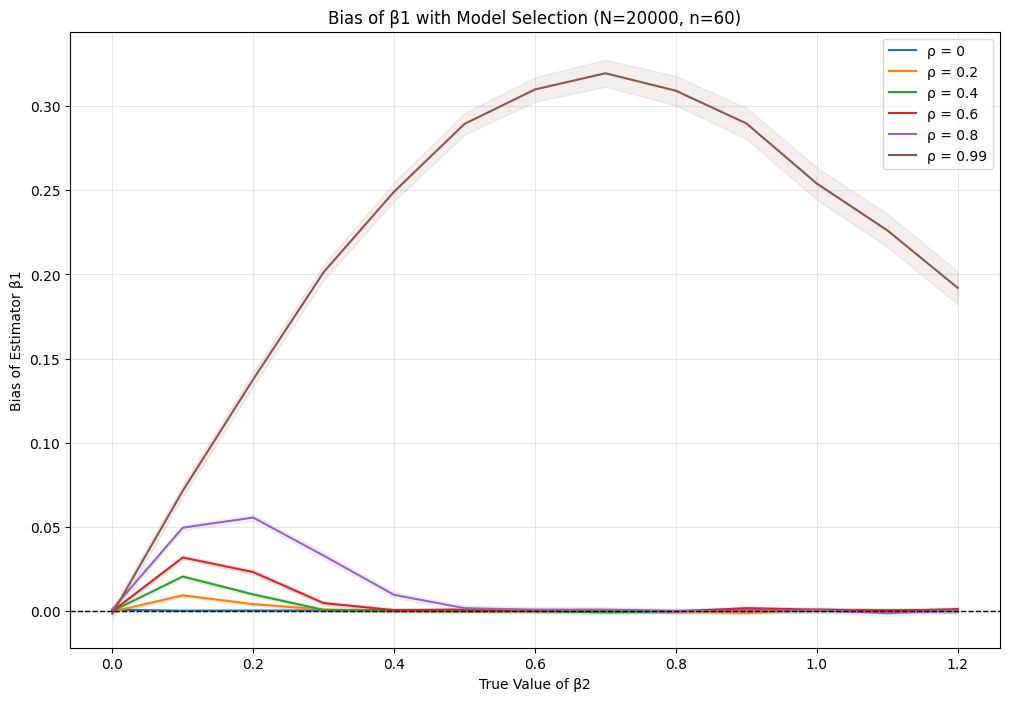

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

#constants
beta1_true = 1.0
sigma_sq = 0.25
alpha = 0.05
n = 60
N = 20000  #number of independent replications

rhos = [0, 0.2, 0.4, 0.6, 0.8, 0.99]
beta2_range = np.arange(0, 1.3, 0.1)

results = []

for rho in rhos:
    # variance(X1)=1, variance(x2)=1, covariance(x1,x2)=rho
    cov_matrix = [[1, rho], [rho, 1]]

    for b2 in beta2_range:
        estimates_b1 = np.zeros(N)

        for r in range(N):
            #generate x1, x2, gaussian
            X = np.random.multivariate_normal([0, 0], cov_matrix, size=n)
            X1, X2 = X[:, 0], X[:, 1]

            #generate y
            e = np.random.normal(0, np.sqrt(sigma_sq), size=n)
            Y = beta1_true * X1 + b2 * X2 + e

            #find p-value for beta2
            X_full = sm.add_constant(np.column_stack((X1, X2)))
            res_3 = sm.OLS(Y, X_full).fit()
            p_val_b2 = res_3.pvalues[2]

            # select model 3(full) if pvalue < alpha, else select model S
            if p_val_b2 < alpha:
                #model 3
                estimates_b1[r] = res_3.params[1]
            else:
                #model S
                X_s = sm.add_constant(X1)
                res_s = sm.OLS(Y, X_s).fit()
                estimates_b1[r] = res_s.params[1]

        #monte carlo standard error
        avg_est = np.mean(estimates_b1)
        bias = avg_est - beta1_true
        std_est = np.std(estimates_b1, ddof=1)
        mc_se = std_est / np.sqrt(N)

        results.append({
            'rho': rho,
            'beta2': b2,
            'bias': bias,
            'mc_se': mc_se
        })


df = pd.DataFrame(results)
plt.figure(figsize=(12, 8))

for rho in rhos:
    subset = df[df['rho'] == rho]
    #95% confidence interval
    ci_upper = subset['bias'] + 1.96 * subset['mc_se']
    ci_lower = subset['bias'] - 1.96 * subset['mc_se']

    line, = plt.plot(subset['beta2'], subset['bias'], label=f'ρ = {rho}')
    plt.fill_between(subset['beta2'], ci_lower, ci_upper, color=line.get_color(), alpha=0.1)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('True Value of β2')
plt.ylabel('Bias of Estimator β1')
plt.title(f'Bias of β1 with Model Selection (N={N}, n={60})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It is statistically indistinguishable from O, when Beta 2 equals to 0. If X2 has no effect, there is no reason for X1 to be biased.

Q1b)

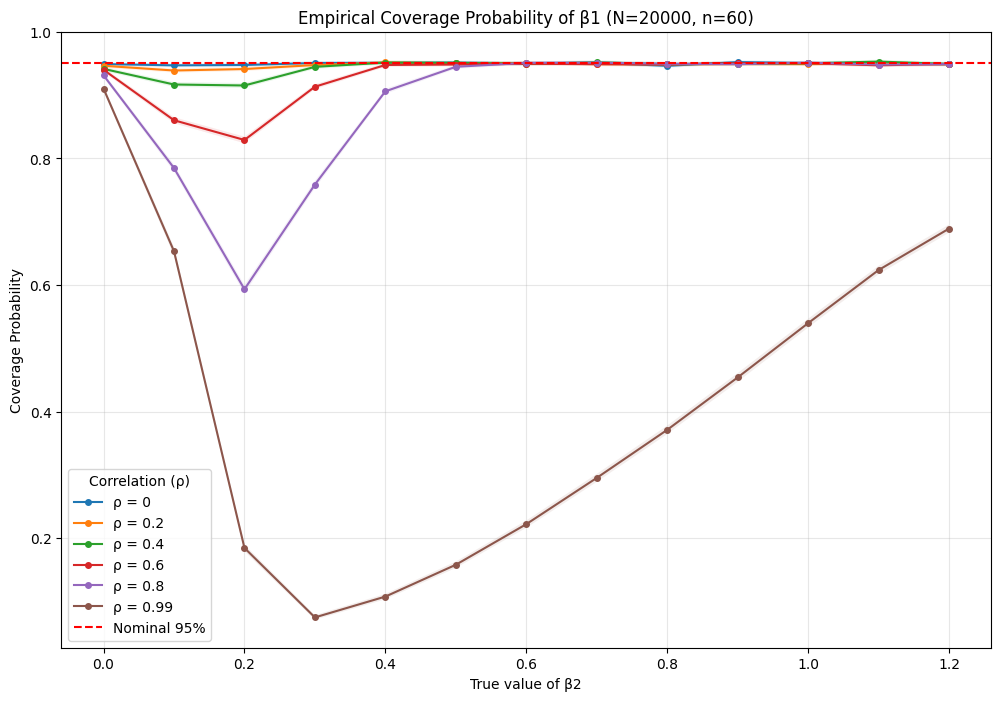

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

#constants
beta1 = 1.0
sigma_sq = 0.25
sigma = np.sqrt(sigma_sq)
alpha = 0.05
n = 60
N = 20000

rhos = [0, 0.2, 0.4, 0.6, 0.8, 0.99]
beta2_range = np.arange(0, 1.3, 0.1)

results = []

for rho in rhos:

    #covariance matrix for X1 and X2
    cov_matrix = [[1, rho], [rho, 1]]

    for b2 in beta2_range:
        coverage_count = 0

        for _ in range(N):
            X = np.random.multivariate_normal([0, 0], cov_matrix, size=n)
            X1, X2 = X[:, 0], X[:, 1]

            eps = np.random.normal(0, sigma, size=n)
            y = beta1 * X1 + b2 * X2 + eps

            #test if beta2 is significant
            full_model = sm.OLS(y, X).fit()
            p_val_beta2 = full_model.pvalues[1]

            #if pvalue is less than alpha, use full model
            if p_val_beta2 < alpha:
                lower, upper = full_model.conf_int(alpha=alpha)[0]
            else:
                #else use model S
                restricted_model = sm.OLS(y, X1).fit()
                lower, upper = restricted_model.conf_int(alpha=alpha)[0]

            #check coverage
            if lower <= beta1 <= upper:
                coverage_count += 1

        cp = coverage_count / N
        mc_se = np.sqrt((cp * (1 - cp)) / N)
        results.append({'rho': rho, 'beta2': b2, 'cp': cp, 'mc_se': mc_se})

df = pd.DataFrame(results)

plt.figure(figsize=(12, 8))

for rho in rhos:
    subset = df[df['rho'] == rho]
    plt.plot(subset['beta2'], subset['cp'], label=f'ρ = {rho}', marker='o', markersize=4)

    #95% Monte Carlo Confidence Intervals
    plt.fill_between(
        subset['beta2'],
        subset['cp'] - 1.96 * subset['mc_se'],
        subset['cp'] + 1.96 * subset['mc_se'],
        alpha=0.1)

plt.axhline(y=0.95, color='r', linestyle='--', label='Nominal 95%')
plt.title(f'Empirical Coverage Probability of β1 (N={N}, n={n})')
plt.xlabel('True value of β2')
plt.ylabel('Coverage Probability')
plt.legend(title='Correlation (ρ)')
plt.grid(True, alpha=0.3)
plt.show()

1. Centered in the wrong place

When Beta2 is in the middle range, it often chooses the Simple Model.
From graph a, When Beta2 is at 0.4 and correlation is at 0.8, there is a positive bias. This means CI isn't centered at 1.
The simple Model has an omitted variable bias, and this simple model gives you an answer with a smaller margin of error. The simple model assumes x2 doesn't exists, hence it thinks there is less noise to worry about.

Q1c)

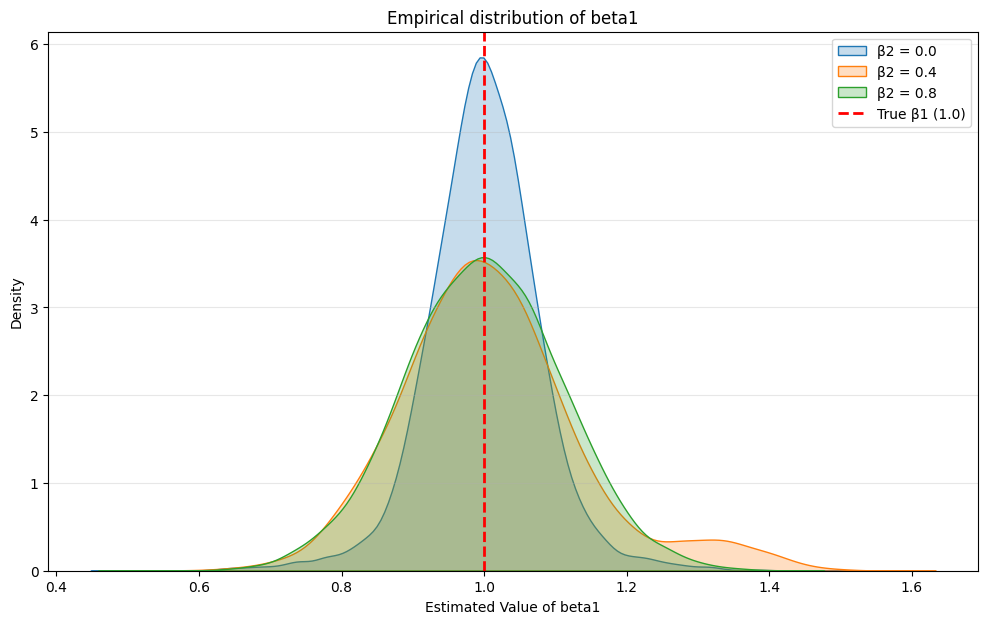

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

#constants
beta1_true = 1.0
sigma_sq = 0.25
alpha = 0.05
n = 60
N = 20000
rho_fix = 0.8
beta2_select = [0.0, 0.4, 0.8]

#covariance matrix for (X1, X2)
cov_matrix = [[1, rho_fix], [rho_fix, 1]]

plt.figure(figsize=(12, 7))

for b2 in beta2_select:
    all_beta1_estimates = []

    for r in range(N):
        X = np.random.multivariate_normal([0, 0], cov_matrix, size=n)
        X1, X2 = X[:, 0], X[:, 1]
        e = np.random.normal(0, np.sqrt(sigma_sq), size=n)
        Y = beta1_true * X1 + b2 * X2 + e

        #Get p-value for beta2
        X_full = sm.add_constant(np.column_stack((X1, X2)))
        res_3 = sm.OLS(Y, X_full).fit()
        p_val_b2 = res_3.pvalues[2]

        #Choose Model 3 if beta 2 less than alpha
        if p_val_b2 < alpha:
            b1_hat = res_3.params[1]
        else:
            X_s = sm.add_constant(X1)
            res_s = sm.OLS(Y, X_s).fit()
            b1_hat = res_s.params[1]

        all_beta1_estimates.append(b1_hat)

    #plot the empirical distribution
    sns.kdeplot(all_beta1_estimates, label=f'β2 = {b2}', fill=True, bw_adjust=1.2)

plt.axvline(beta1_true, color='red', linestyle='--', linewidth=2, label='True β1 (1.0)')

plt.title(f'Empirical distribution of beta1')
plt.xlabel('Estimated Value of beta1')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Weight of component = how much of the distribution is made up of Model 3 vs Model S. It's determined by how easy for the t-test to see X2, which depends on the size of Beta2, sample size and noise.

Q1d)

$$E[\hat{\beta}_1] = w \cdot E[\hat{\beta}_3] + (1-w) \cdot E[\hat{\beta}_S]$$


Given that $E[\hat{\beta}_3] = \beta_1$ (unbiased) and $E[\hat{\beta}_S] = \beta_1 + \rho \beta_2$ (biased)

 $$\text{Bias} = (1-w) \cdot (\rho \beta_2)$$



When Beta2 is low the term $\rho \beta_2$ is tiny, even if the chances of you picking the simple model is high, the amount of credit stolen is tiny.

When Beta2 is high, the (1−𝑤) drops to nearly 0. It almost never lets you pick the simple model

When Beta2 is in the middle, $\rho \beta_2$  is large enough to matter, but the ((1−𝑤) is still high because t-test isnt strong enough tp catch X2 all the time. There is high amount of bias in this case.